# Exploratory Climate Data Analysis & Environmental Metric Modeling

## The Weather Dataset

### Here, The Weather Dataset is a time-series data set with per-hour information about the weather conditions at a particular location. It records Temperature, Dew Point Temperature, Relative Humidity, Wind Speed, Visibility, Pressure, and Conditions.

### This data is available as a CSV file. We are going to analyze this data set using the Numpy, Pandas, Matplotlib, Seaborn DataFrame.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

try:
    df = pd.read_csv("weather_data.csv") 
    print("✅ Success: Data loaded into variable 'df'!")
    print(f"Data Shape: {df.shape[0]} Rows, {df.shape[1]} Columns")
except FileNotFoundError:
    print("❌ Error: Could not find 'weather_data.csv'. Please check the file name and location.")

✅ Success: Data loaded into variable 'df'!
Data Shape: 8784 Rows, 8 Columns


In [3]:
#DATA CLEANING & PRE-PROCESSING
df.rename(columns={
    'Weather': 'Weather_Condition',
    'Rel Hum_%': 'Rel_Hum',
    'Wind Speed_km/h': 'Wind_Speed',
    'Visibility_km': 'Visibility',
    'Press_kPa': 'Pressure'
}, inplace=True)

print("✅ Columns renamed successfully!")
print("New Column Names:", df.columns.tolist())

# Check for Null Values (Data Integrity)
null_count = df.isnull().sum().sum()
print(f"Total Null Values detected: {null_count}")

✅ Columns renamed successfully!
New Column Names: ['Date/Time', 'Temp_C', 'Dew Point Temp_C', 'Rel_Hum', 'Wind_Speed', 'Visibility', 'Pressure', 'Weather_Condition']
Total Null Values detected: 0


In [29]:
df['Date/Time'] = pd.to_datetime(df['Date/Time'])

print(df.dtypes)

Date/Time            datetime64[ns]
Temp_C                      float64
Dew Point Temp_C            float64
Rel_Hum                       int64
Wind_Speed                    int64
Visibility                  float64
Pressure                    float64
Weather_Condition            object
Hour                          int32
Month                         int32
Month_Name                   object
dtype: object


In [27]:
df['Hour'] = df['Date/Time'].dt.hour
df['Month'] = df['Date/Time'].dt.month
df['Month_Name'] = df['Date/Time'].dt.strftime('%b') 

df[['Date/Time', 'Hour', 'Month', 'Month_Name']].head()

,Date/Time,Hour,Month,Month_Name
0,2012-01-01 00:00:00,0,1,Jan
1,2012-01-01 01:00:00,1,1,Jan
2,2012-01-01 02:00:00,2,1,Jan
3,2012-01-01 03:00:00,3,1,Jan
4,2012-01-01 04:00:00,4,1,Jan


# ==========================================
#  EXPLORATORY DATA ANALYSIS 
# ==========================================

In [4]:
df.head()

,Date/Time,Temp_C,Dew Point Temp_C,Rel_Hum,Wind_Speed,Visibility,Pressure,Weather_Condition
0,1/1/2012 0:00,-1.8,-3.9,86,4,8.0,101.24,Fog
1,1/1/2012 1:00,-1.8,-3.7,87,4,8.0,101.24,Fog
2,1/1/2012 2:00,-1.8,-3.4,89,7,4.0,101.26,"Freezing Drizzle,Fog"
3,1/1/2012 3:00,-1.5,-3.2,88,6,4.0,101.27,"Freezing Drizzle,Fog"
4,1/1/2012 4:00,-1.5,-3.3,88,7,4.8,101.23,Fog


In [5]:
df.tail()

,Date/Time,Temp_C,Dew Point Temp_C,Rel_Hum,Wind_Speed,Visibility,Pressure,Weather_Condition
8779,12/31/2012 19:00,0.1,-2.7,81,30,9.7,100.13,Snow
8780,12/31/2012 20:00,0.2,-2.4,83,24,9.7,100.03,Snow
8781,12/31/2012 21:00,-0.5,-1.5,93,28,4.8,99.95,Snow
8782,12/31/2012 22:00,-0.2,-1.8,89,28,9.7,99.91,Snow
8783,12/31/2012 23:00,0.0,-2.1,86,30,11.3,99.89,Snow


##  Q1. Find all unique 'Wind Speed' values

In [6]:
print("--- Unique Wind Speeds ---")
print(df['Wind_Speed'].unique())

--- Unique Wind Speeds ---
[ 4  7  6  9 15 13 20 22 19 24 30 35 39 32 33 26 44 43 48 37 28 17 11  0
 83 70 57 46 41 52 50 63 54  2]


## Q2. Find the number of times when the 'Weather is exactly Clear'

In [7]:
clear_weather = df[df['Weather_Condition'] == 'Clear']
print(f"\n--- Total 'Clear' Weather Observations: {len(clear_weather)} ---")


--- Total 'Clear' Weather Observations: 1326 ---


## Q3. Find the number of times 'Wind Speed was exactly 4 km/h'

In [8]:
wind_4kmh = df[df['Wind_Speed'] == 4]
print(f"--- Count of Wind Speed at 4 km/h: {len(wind_4kmh)} ---")

--- Count of Wind Speed at 4 km/h: 474 ---


## Q4. Standard Deviation of Pressure

In [10]:
print(f"Pressure Std Dev: {df['Pressure'].std():.2f} kPa")

Pressure Std Dev: 0.84 kPa


## Q5. Variance of Relative Humidity

In [15]:
print(f"Humidity Variance: {df['Rel_Hum'].var():.2f}")

Humidity Variance: 286.25


## Q6. Find all instances when 'Snow' was recorded

In [16]:
# We use str.contains to catch 'Snow', 'Snow Showers', etc
snow_records = df[df['Weather_Condition'].str.contains('Snow', na=False)]
print(f"Total Snow Recordings: {len(snow_records)}")

Total Snow Recordings: 583


## Q7. Find instances when 'Wind Speed > 24' and 'Visibility == 25'

In [17]:
high_wind_vis = df[(df['Wind_Speed'] > 24) & (df['Visibility'] == 25)]
print(f"High Wind & Good Visibility Counts: {len(high_wind_vis)}")

High Wind & Good Visibility Counts: 308


## Q8. Complex Filtering
## A. 'Weather is Clear' and 'Relative Humidity > 50'
## OR B. 'Visibility > 40'

In [20]:
complex_query = df[((df['Weather_Condition'] == 'Clear') & (df['Rel_Hum'] > 50)) | (df['Visibility'] > 40)]
print(f"\n--- Complex Query Matches: {len(complex_query)} rows found ---")


--- Complex Query Matches: 2921 rows found ---


# ==========================================
#  DATA VISUALIZATION
# ==========================================

## Key Analytical Insight: Core Variable Correlations

## Strong Positive Relationship: A massive 0.93 correlation exists between Temp_C and Dew Point Temp_C. This is expected, as the dew point is directly bound by ambient temperature thresholds.

## Strong Negative Relationship: A notable -0.63 correlation stands out between Visibility and Rel_Hum. This suggests that high-humidity conditions (like fog, mist, or heavy drizzle) strongly impair environmental visibility, a crucial factor for transport logistics safety metrics.

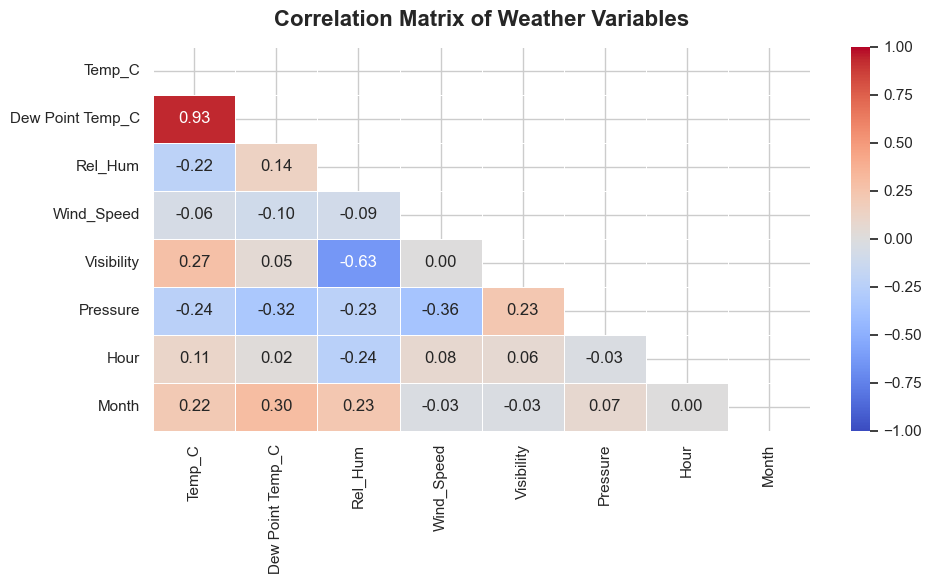

In [30]:
# Shows how variables like Temperature and Humidity relate to each other
plt.figure(figsize=(10, 6))

corr_matrix = df.corr(numeric_only=True)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    vmin=-1, 
    vmax=1,
    linewidths=0.5  
)

plt.title('Correlation Matrix of Weather Variables', fontsize=16, fontweight='bold', pad=15)

plt.tight_layout()  
plt.show()

## Key Analytical Insight: Diurnal Temperature Cycle

## Observation: The line chart reveals a textbook diurnal temperature variation. The daily minimum temperature occurs around 5:00 AM (~5.7°C), immediately before sunrise. 

## The temperature rises consistently throughout the morning, peaking at 3:00 PM (~11.9°C) due to peak solar radiation accumulation, before steadily dropping post-sunset.

## Data Utility: For predictive modeling or forecasting weather conditions, the Hour feature engineered from the timestamp acts as a highly critical cyclic predictor.

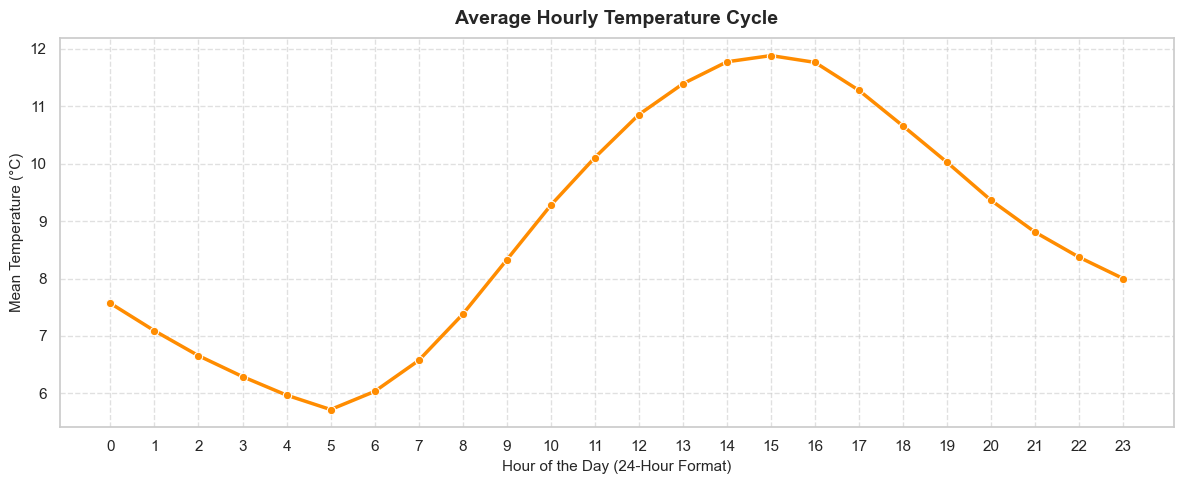

In [28]:
plt.figure(figsize=(12, 5))

hourly_temp = df.groupby('Hour')['Temp_C'].mean()

sns.lineplot(x=hourly_temp.index, y=hourly_temp.values, marker="o", color="darkorange", linewidth=2.5)

plt.title('Average Hourly Temperature Cycle', fontsize=14, fontweight='bold', pad=10)
plt.xlabel('Hour of the Day (24-Hour Format)', fontsize=11)
plt.ylabel('Mean Temperature (°C)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(range(0, 24))

plt.tight_layout()
plt.show()

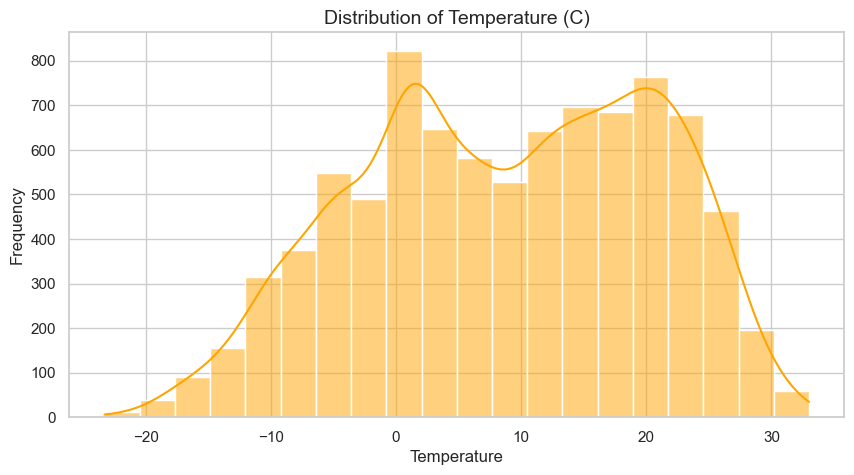

In [22]:
# Shows the spread of temperature data
plt.figure(figsize=(10, 5))
sns.histplot(df['Temp_C'], bins=20, kde=True, color='orange')
plt.title('Distribution of Temperature (C)', fontsize=14)
plt.xlabel('Temperature')
plt.ylabel('Frequency')
plt.show()

## Key Analytical Insight: The Inverse Temperature-Humidity Relationship

## Observation: The negative slope of the red regression line visually confirms the -0.22 correlation coefficient found in our global matrix. As ambient temperature (Temp_C) increases, the relative humidity (Rel_Hum) shows a downward trend.

## Meteorological Context: Warmer air has a higher capacity to hold water vapor without saturating, meaning that even if the absolute moisture remains constant, the relative humidity drops as the day warms up.

<Axes: xlabel='Temp_C', ylabel='Rel_Hum'>

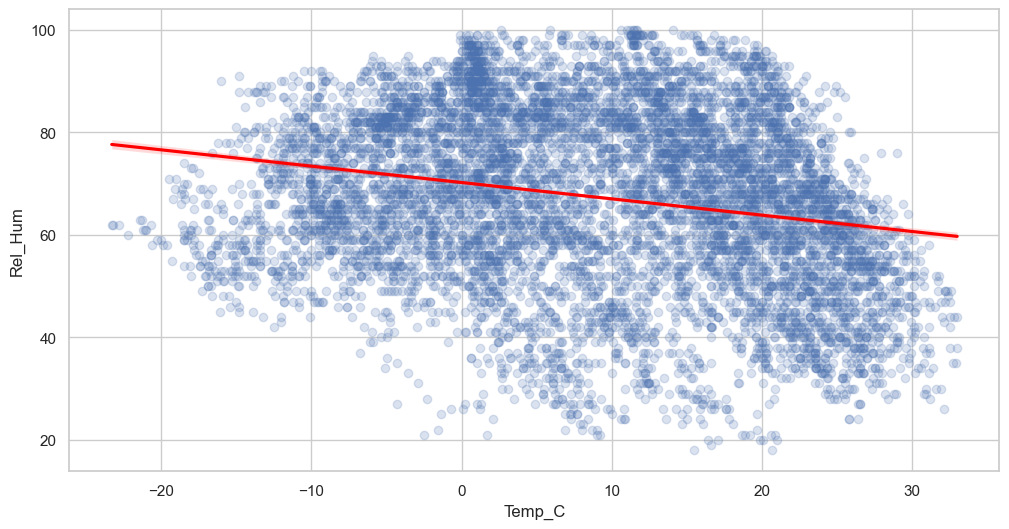

In [25]:
# Shows the inverse relationship (as Temp goes up, Humidity goes down)
sns.regplot(data=df, x='Temp_C', y='Rel_Hum', scatter_kws={'alpha':0.2}, line_kws={'color':'red'})